Before Removing:  102
After Removing:  50
Index(['pid', 'match', 'date', 'attr', 'sinc', 'intel', 'fun', 'amb', 'like',
       'prob', 'date_p', 'attr_p', 'sinc_p', 'intel_p', 'fun_p', 'amb_p',
       'like_p', 'prob_p', 'sports_difference', 'tvsports_difference',
       'exercise_difference', 'dining_difference', 'museums_difference',
       'art_difference', 'hiking_difference', 'gaming_difference',
       'clubbing_difference', 'reading_difference', 'tv_difference',
       'theater_difference', 'movies_difference', 'concerts_difference',
       'music_difference', 'shopping_difference', 'yoga_difference',
       'go_out_difference', 'imprelig_difference', 'imprace_difference',
       'date_difference', 'attr_difference', 'sinc_difference',
       'intel_difference', 'fun_difference', 'amb_difference',
       'like_difference', 'prob_difference', 'age_o_difference', 'same_career',
       'same_field', 'pref_diff_score'],
      dtype='object')
0.17


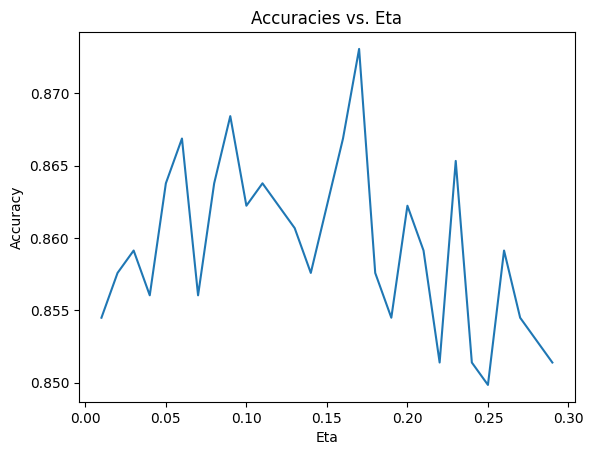

6


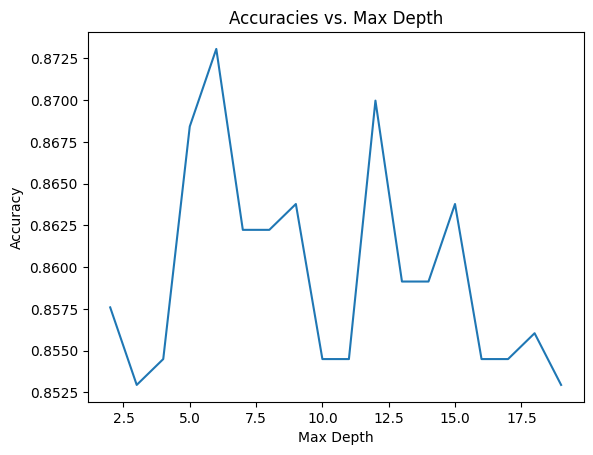

1.0
{'objective': 'binary:logistic', 'use_label_encoder': None, 'base_score': 0.5, 'booster': 'gbtree', 'callbacks': None, 'colsample_bylevel': 1, 'colsample_bynode': 1, 'colsample_bytree': 1, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': None, 'feature_types': None, 'gamma': 0, 'gpu_id': -1, 'grow_policy': 'depthwise', 'importance_type': None, 'interaction_constraints': '', 'learning_rate': 0.170000002, 'max_bin': 256, 'max_cat_threshold': 64, 'max_cat_to_onehot': 4, 'max_delta_step': 0, 'max_depth': 6, 'max_leaves': 0, 'min_child_weight': 4.9, 'missing': nan, 'monotone_constraints': '()', 'n_estimators': 100, 'n_jobs': 0, 'num_parallel_tree': 1, 'predictor': 'auto', 'random_state': 0, 'reg_alpha': 0, 'reg_lambda': 1, 'sampling_method': 'uniform', 'scale_pos_weight': 1, 'subsample': 1, 'tree_method': 'exact', 'validate_parameters': 1, 'verbosity': None, 'eta': 0.17}


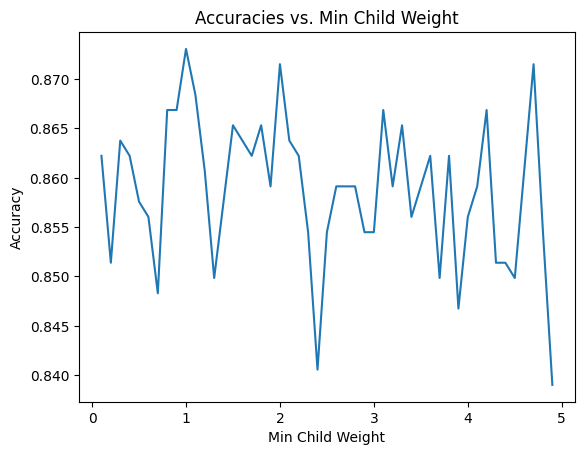

In [13]:
import xgboost as xgb
import pandas as pd
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.metrics import precision_score, recall_score, accuracy_score
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt

df = pd.read_csv('Cleaned_Data.csv')
print("Before Removing: ", str(len(df.columns)))
removeColumns = ["from","same_from", "imprace", "imprelig", "samerace",  'p_iid', 'p_pid', 'imprace_p', 'imprelig_p', 'go_out_p', 'career_c_p', 'sports_p', 'tvsports_p', 'dining_p', 'museums_p', 'art_p', 'hiking_p', 'gaming_p', 'clubbing_p', 'reading_p', 'tv_p', 'theater_p', 'movies_p', 'concerts_p', 'music_p', 'shopping_p', 'yoga_p', 'iid', 'gender', 'field_cd', 'go_out', 'career_c', 'tvsports', 'dining', 'art', 'hiking', 'gaming', 'clubbing', 'tv', 'movies', 'concerts', 'music', 'shopping', 'yoga', 'sports', 'exercise', 'museums', 'reading', 'theater', 'field_cd_p', 'from_p', 'exercise_p']
df = df.drop(columns=removeColumns)
print("After Removing: ", str(len(df.columns)))

data = df.loc[:, df.columns != 'match']
print(df.columns)
labels = df['match']

from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(data, labels, test_size=0.2, random_state=21)

clf = xgb.XGBClassifier()
parameters = {
     "eta"    : [0.1, 0.2, 0.25, 0.3] ,
     "max_depth"        : [2 ,3, 8, 10, 15, 20],
     "min_child_weight" : [0.1, 0.5, 0.8 ,1, 7, 10 ],
     'objective': ['binary:logistic', 'binary:hinge']
     }
accuracies = []
for eta in [x/100 for x in range(1,30)]:
     model = xgb.XGBClassifier(eta=eta)
     model.fit(X_train, Y_train)
     accuracies.append(model.score(X_test,Y_test))
best_eta = (accuracies.index(max(accuracies)) + 1 )/100
print((accuracies.index(max(accuracies)) + 1 )/100)

plt.plot([x/100 for x in range(1,30)], accuracies)
plt.title("Accuracies vs. Eta")
plt.xlabel("Eta")
plt.ylabel("Accuracy")
plt.show()


accuracies = []
for max_depth in range(2,20):
     model = xgb.XGBClassifier(eta=best_eta, max_depth=max_depth)
     model.fit(X_train, Y_train)
     accuracies.append(model.score(X_test,Y_test))
best_max_depth = accuracies.index(max(accuracies)) + 2 
print(accuracies.index(max(accuracies)) + 2 )

plt.plot(list(range(2,20)), accuracies)
plt.title("Accuracies vs. Max Depth")
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.show()

accuracies = []
for min_child_weight in [x/10 for x in range(1,50)]:
     model = xgb.XGBClassifier(eta=best_eta, max_depth=best_max_depth, min_child_weight=min_child_weight)
     model.fit(X_train, Y_train)
     accuracies.append(model.score(X_test,Y_test))
best_min_child_weight = (accuracies.index(max(accuracies)) + 1 )/100
print((accuracies.index(max(accuracies)) + 1)/10 )
print(model.get_params())
plt.plot([x/10 for x in range(1,50)], accuracies)
plt.title("Accuracies vs. Min Child Weight")
plt.xlabel("Min Child Weight")
plt.ylabel("Accuracy")
plt.show()


In [20]:

# grid = GridSearchCV(clf,
#                     parameters, n_jobs=4,
#                     scoring="accuracy",
#                     cv=3)

# grid.fit(X_train, Y_train)
# best = grid.best_estimator_
# best_preds = best.predict(X_test)
# print(grid.best_params_)

# print("Precision = {}".format(precision_score(Y_test, best_preds, average='macro')))
# print("Recall = {}".format(recall_score(Y_test, best_preds, average='macro')))
# print("Accuracy = {}".format(accuracy_score(Y_test, best_preds)))

multiclassModel = xgb.XGBClassifier()

parameters = {
     "eta"    : [x/100 for x in range(1,15)] ,
     "max_depth"        : list(range(2,10)),
     "min_child_weight" : [x/10 for x in range(1,30)],
     'objective': ['multi:softmax'],
     'num_class': [2]
     }

grid = GridSearchCV(multiclassModel,
                    parameters, n_jobs=-1,
                    scoring="accuracy",
                    cv=3)

grid.fit(X_train, Y_train)
best = grid.best_estimator_
best_preds = best.predict(X_test)
print("Multiclass Best params: ", grid.best_params_)
print("Multiclass Precision = {}".format(precision_score(Y_test, best_preds, average='macro')))
print("Multiclass Recall = {}".format(recall_score(Y_test, best_preds, average='macro')))
print("Multiclass Accuracy = {}".format(accuracy_score(Y_test, best_preds)))
results = pd.DataFrame(grid.cv_results_)
results.to_csv("gridSearchResults.csv")
# sfs = SFS(best, forward = True, k_features = 'best', n_jobs = -1)
# sfs.fit(X_train, Y_train)
# features = list(sfs.k_feature_names_)
# best.fit(X_train[features], Y_train)
# best_preds = best.predict(X_test[features])
# print(features)
# print("Feature Selected Multiclass Best params: ", grid.best_params_)
# print("Feature Selected Multiclass Precision = {}".format(precision_score(Y_test, best_preds, average='macro')))
# print("Feature Selected Multiclass Recall = {}".format(recall_score(Y_test, best_preds, average='macro')))
# print("Feature Selected Multiclass Accuracy = {}".format(accuracy_score(Y_test, best_preds)))

Multiclass Best params:  {'eta': 0.1, 'max_depth': 9, 'min_child_weight': 1.3, 'num_class': 2, 'objective': 'multi:softmax'}
Multiclass Precision = 0.763505302695537
Multiclass Recall = 0.6630020672099499
Multiclass Accuracy = 0.8591331269349846


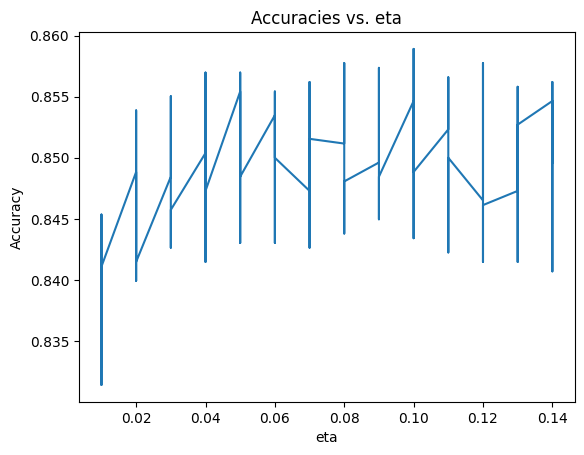

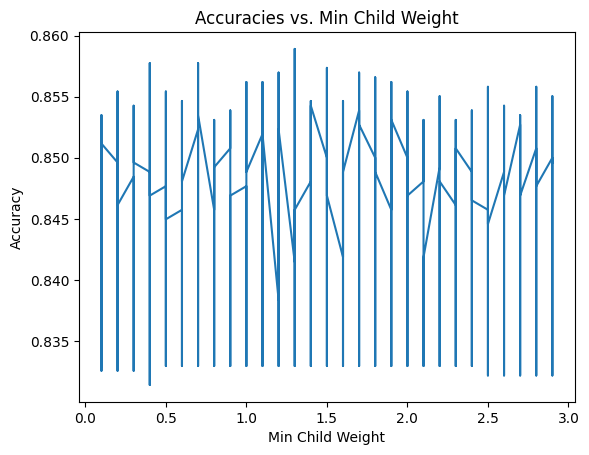

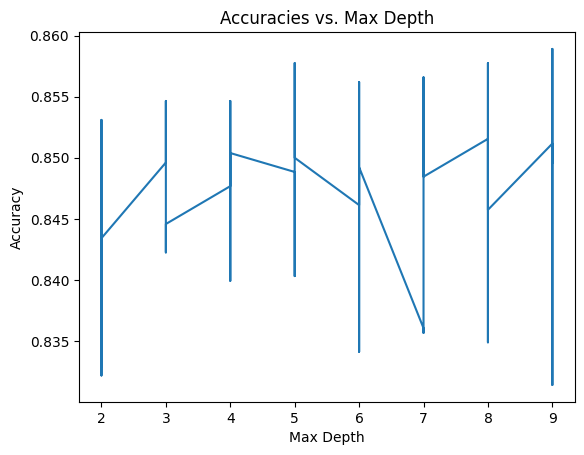

In [25]:
results = pd.read_csv("gridSearchResults.csv")


eta = results.sort_values("param_eta")["param_eta"]
accuraciesEta = results.sort_values("param_eta")["mean_test_score"]

min_child_weight = results.sort_values("param_min_child_weight")["param_min_child_weight"]
accuraciesMCW = results.sort_values("param_min_child_weight")["mean_test_score"]

max_depth = results.sort_values("param_max_depth")['param_max_depth']
accuraciesMD = results.sort_values("param_max_depth")["mean_test_score"]

plt.plot(eta.sort_values(), accuraciesEta)
plt.title("Accuracies vs. eta")
plt.xlabel("eta")
plt.ylabel("Accuracy")
plt.show()

plt.plot(min_child_weight, accuraciesMCW)
plt.title("Accuracies vs. Min Child Weight")
plt.xlabel("Min Child Weight")
plt.ylabel("Accuracy")
plt.show()

plt.plot(max_depth, accuraciesMD)
plt.title("Accuracies vs. Max Depth")
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.show()